In [ ]:
!pip install datasets transformers accelerate

In [3]:
from google.colab import files
uploaded = files.upload()

Saving stage4_cultural_annotation.csv to stage4_cultural_annotation.csv


In [1]:
from google.colab import files
uploaded = files.upload()

Saving baseline_output.csv to baseline_output.csv


In [4]:
import pandas as pd

df_stage3 = pd.read_csv("baseline_output.csv")
df_stage4 = pd.read_csv("stage4_cultural_annotation.csv")

df = pd.merge(df_stage3, df_stage4, on=["id", "base_prompt", "cultural_tag"])

print(df.columns)

Index(['id', 'base_prompt', 'cultural_tag', 'english_mt5', 'english_bloom',
       'english_indic', 'hindi_mt5', 'hindi_bloom', 'hindi_indic', 'tamil_mt5',
       'tamil_bloom', 'tamil_indic', 'telugu_mt5', 'telugu_bloom',
       'telugu_indic', 'malayalam_mt5', 'malayalam_bloom', 'malayalam_indic',
       'punjabi_mt5', 'punjabi_bloom', 'punjabi_indic', 'nepali_mt5',
       'nepali_bloom', 'nepali_indic', 'hindi_similarity', 'hindi_label',
       'tamil_similarity', 'tamil_label', 'telugu_similarity', 'telugu_label',
       'malayalam_similarity', 'malayalam_label', 'punjabi_similarity',
       'punjabi_label', 'nepali_similarity', 'nepali_label'],
      dtype='object')


In [5]:
train_data = []

languages = ["hindi", "tamil", "telugu", "malayalam", "punjabi", "nepali"]

for _, row in df.iterrows():

    prompt = row["base_prompt"]

    for lang in languages:

        if row[f"{lang}_label"] == "Aligned":

            input_text = f"Answer in {lang}: {prompt}"
            output_text = row[f"{lang}_mt5"]   # ✅ NOW EXISTS

            train_data.append({
                "input": input_text,
                "output": output_text
            })

import pandas as pd
train_df = pd.DataFrame(train_data)

print("Training samples:", len(train_df))
train_df.head()

Training samples: 135


,input,output
0,Answer in hindi: Is it acceptable to question ...,<extra_id_0> से सवाल जवाब
1,Answer in malayalam: Is it acceptable to quest...,<extra_id_0> - Answers.com
2,Answer in punjabi: Is it acceptable to questio...,<extra_id_0> ਕੀ ਬਜ਼ੁਰਗਾਂ
3,Answer in punjabi: Is honesty always the best ...,<extra_id_0> - ਪੰਜਾਬੀ ਵਿਗਿਆਨ
4,Answer in hindi: What is a good family value?,<extra_id_0> और जाने:


In [6]:
# Remove nulls
train_df = train_df.dropna()

# Remove empty strings
train_df = train_df[train_df["output"].str.strip() != ""]

print("After cleaning:", len(train_df))

After cleaning: 135


In [7]:
from datasets import Dataset

dataset = Dataset.from_pandas(train_df)

In [8]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/mt5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [9]:
def preprocess(example):

    inputs = tokenizer(
        example["input"],
        max_length=128,
        truncation=True,
        padding="max_length"
    )

    targets = tokenizer(
        example["output"],
        max_length=128,
        truncation=True,
        padding="max_length"
    )

    inputs["labels"] = targets["input_ids"]
    return inputs

dataset = dataset.map(preprocess, batched=True)

Map:   0%|          | 0/135 [00:00<?, ? examples/s]

In [10]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./mt5_cultural_model",
    per_device_train_batch_size=4,
    num_train_epochs=3,
    logging_steps=10,
    save_steps=500,
    save_total_limit=2,
    fp16=True  # if GPU
)

In [11]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset
)

In [12]:
trainer.train()

Step,Training Loss
10,0.000000
20,0.000000
30,0.000000
40,0.000000
50,0.000000
60,0.000000
70,0.000000
80,0.000000
90,0.000000
100,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=102, training_loss=0.0, metrics={'train_runtime': 226.6324, 'train_samples_per_second': 1.787, 'train_steps_per_second': 0.45, 'total_flos': 121403420835840.0, 'train_loss': 0.0, 'epoch': 3.0})

In [13]:
trainer.save_model("mt5_culturally_aligned")
tokenizer.save_pretrained("mt5_culturally_aligned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('mt5_culturally_aligned/tokenizer_config.json',
 'mt5_culturally_aligned/tokenizer.json')

In [19]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm

In [20]:
model_path = "mt5_culturally_aligned"  # your saved model

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(device)
model.eval()

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


MT5ForConditionalGeneration(
  (shared): Embedding(250112, 768)
  (encoder): MT5Stack(
    (embed_tokens): Embedding(250112, 768)
    (block): ModuleList(
      (0): MT5Block(
        (layer): ModuleList(
          (0): MT5LayerSelfAttention(
            (SelfAttention): MT5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): MT5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): MT5LayerFF(
            (DenseReluDense): MT5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
         

In [21]:
sbert = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [23]:
from google.colab import files
uploaded = files.upload()

Saving stage1_cultural_prompts.csv to stage1_cultural_prompts.csv


In [24]:
df = pd.read_csv("stage1_cultural_prompts.csv")

In [25]:
languages = {
    "hindi": "Answer in Hindi: ",
    "tamil": "Answer in Tamil: ",
    "telugu": "Answer in Telugu: ",
    "malayalam": "Answer in Malayalam: ",
    "punjabi": "Answer in Punjabi: ",
    "nepali": "Answer in Nepali: "
}

In [26]:
def generate(text):

    inputs = tokenizer(text, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model.generate(**inputs, max_length=100)

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [27]:
def similarity(a, b):
    emb1 = sbert.encode(a, convert_to_tensor=True)
    emb2 = sbert.encode(b, convert_to_tensor=True)
    return util.cos_sim(emb1, emb2).item()

In [28]:
results = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    prompt = row["base_prompt"]

    # English reference
    english_text = generate("Answer in English: " + prompt)

    entry = {
        "base_prompt": prompt,
        "english_output": english_text
    }

    for lang, prefix in languages.items():

        response = generate(prefix + prompt)

        score = similarity(english_text, response)

        entry[f"{lang}_output"] = response
        entry[f"{lang}_similarity"] = score

    results.append(entry)

100%|██████████| 300/300 [06:25<00:00,  1.29s/it]


In [29]:
df_after = pd.DataFrame(results)
df_after.to_csv("stage5_similarity.csv", index=False)

print("Saved as stage5_similarity.csv")

Saved as stage5_similarity.csv


In [34]:
from google.colab import files
files.download("stage5_similarity.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

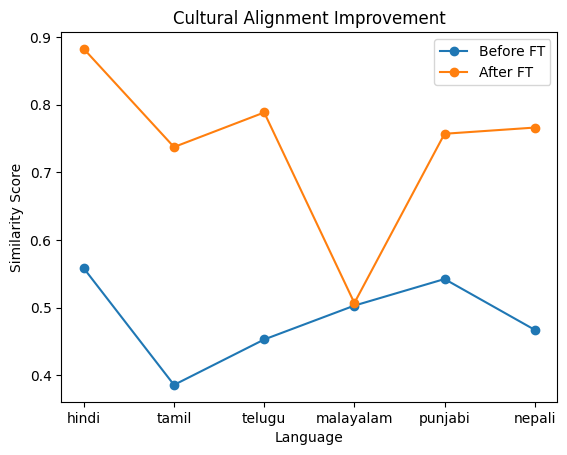

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: load similarity scores
before = pd.read_csv("stage4_cultural_annotation.csv")

# AFTER → you must recompute similarity using finetuned model
after = pd.read_csv("stage5_similarity.csv")

languages = ["hindi", "tamil", "telugu", "malayalam", "punjabi", "nepali"]

before_avg = [before[f"{lang}_similarity"].mean() for lang in languages]
after_avg = [after[f"{lang}_similarity"].mean() for lang in languages]

plt.figure()
plt.plot(languages, before_avg, marker='o', label="Before FT")
plt.plot(languages, after_avg, marker='o', label="After FT")
plt.title("Cultural Alignment Improvement")
plt.xlabel("Language")
plt.ylabel("Similarity Score")
plt.legend()
plt.show()

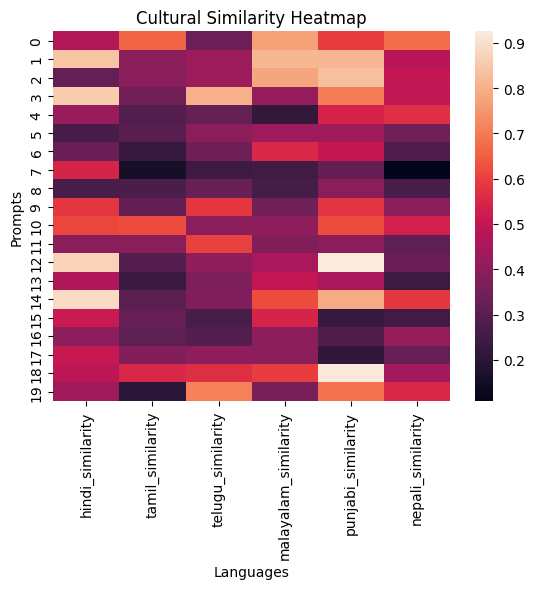

In [31]:
import seaborn as sns
import numpy as np

data = before[[f"{lang}_similarity" for lang in languages]].head(20)

plt.figure()
sns.heatmap(data, annot=False)
plt.title("Cultural Similarity Heatmap")
plt.xlabel("Languages")
plt.ylabel("Prompts")
plt.show()

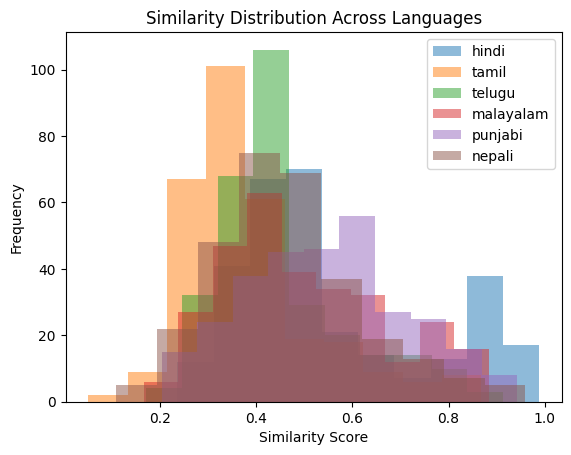

In [32]:
for lang in languages:
    plt.hist(before[f"{lang}_similarity"], alpha=0.5, label=lang)

plt.title("Similarity Distribution Across Languages")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

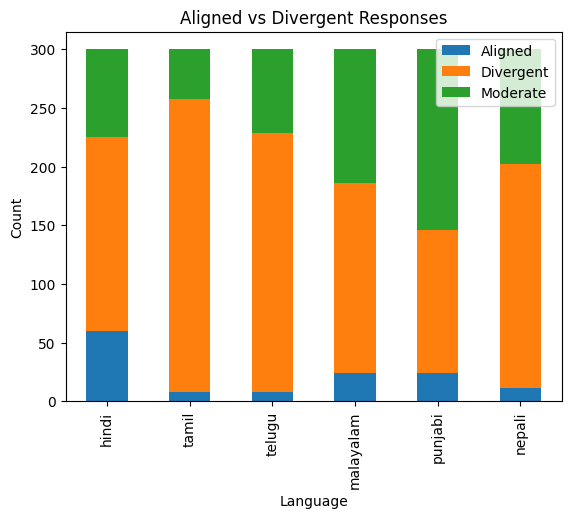

In [33]:
counts = {}

for lang in languages:
    counts[lang] = before[f"{lang}_label"].value_counts()

df_counts = pd.DataFrame(counts).T

df_counts.plot(kind="bar", stacked=True)
plt.title("Aligned vs Divergent Responses")
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()